In [ ]:
# =====================================================
# 1. DATA UNDERSTANDING
# =====================================================

# 1.1 Import Required Libraries
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1.2 Load Dataset
df = pd.read_csv("/content/School Bullying Survey (Responses) - Form Responses 1.csv")

# 1.3 Initial Data Inspection
print(df.head())
print(df.info())
print(df.shape)


             Timestamp Age  Gender                       School Level  \
0  10/27/2025 22:40:49  21  Female  College/Pre-University/University   
1  10/27/2025 22:40:52  22  Female  College/Pre-University/University   
2  10/27/2025 22:43:36  17  Female                   Secondary School   
3  10/27/2025 22:44:55  21  Female  College/Pre-University/University   
4  10/27/2025 22:47:53  12  Female                     Primary School   

  What is the size of your class?\n(Please enter the total number of students in your class.)  \
0                                                 50                                            
1                                                60+                                            
2                                                 48                                            
3                                                400                                            
4                                                 29                        

In [ ]:
# =====================================================
# 2. DATA PREPROCESSING
# =====================================================

# =====================================================
# PART 1: COLUMN NAME STANDARDIZATION
# =====================================================

df.columns = (
    df.columns
    .str.strip()
    .str.replace('\n', '_')
    .str.replace(' ', '_')
    .str.lower()
)

df.rename(columns={
    'what_is_the_size_of_your_class?_(please_enter_the_total_number_of_students_in_your_class.)': 'class_size',
    'how_much_support_do_you_get_from_your_siblings?': 'sibling_support',
    'how_many_close_friends_do_you_have_at_school?': 'num_close_friends',
    'have_you_ever_been_bullied_at_school': 'bullied',
    'if_yes,_what_type_of_bullying_have_you_experienced?_(select_all_that_apply)': 'bullying_type',
    'how_often_have_you_experienced_this_bullying?': 'bullying_frequency',
    'what_do_you_usually_do_when_someone_bullies_you?_(select_all_that_apply)': 'bullying_response'
}, inplace=True)



In [ ]:
# =====================================================
# PART 2: AGE CLEANING & FILTERING
# =====================================================

df['age'] = pd.to_numeric(df['age'], errors='coerce')
df = df[df['age'] > 12]   # remove age <= 12


In [ ]:
# =====================================================
# PART 3: SCHOOL LEVEL CORRECTION
# =====================================================

def correct_school_level(age):
    if 13 <= age <= 17:
        return "Secondary"
    elif age >= 18:
        return "University"
    else:
        return np.nan

df['school_level'] = df['age'].apply(correct_school_level)
df = df[df['school_level'].notna()]


In [ ]:
# =====================================================
# PART 4: CLASS SIZE CLEANING & OUTLIER HANDLING
# =====================================================

def clean_class_size(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower()
    x = re.sub(r'[^\d\-\+]', '', x)
    if '-' in x:
        numbers = re.findall(r'\d+', x)
        return int(numbers[-1]) if numbers else np.nan
    numbers = re.findall(r'\d+', x)
    return int(numbers[0]) if numbers else np.nan

df['class_size'] = df['class_size'].apply(clean_class_size)
df['class_size'] = df['class_size'].fillna(df['class_size'].median())

# Cap class size at 95th percentile to reduce extreme impact
class_size_95 = df['class_size'].quantile(0.95)
df['class_size'] = df['class_size'].apply(lambda x: min(x, class_size_95))


In [ ]:
# =====================================================
# PART 5: BINARY ENCODING
# =====================================================

df['gender'] = df['gender'].str.lower().map({'male': 1, 'female': 0})
df['bullied'] = df['bullied'].str.lower().map({'yes': 1, 'no': 0})


In [ ]:
# =====================================================
# PART 6: ORDINAL ENCODING
# =====================================================

ordinal_maps = {
    'sibling_support': {'Never':1, 'Sometimes':2, 'Often':3, 'Always':4},
    'how_often_is_there_conflict_at_home?': {'Never':1, 'Sometimes':2, 'Often':3, 'Always':4},
    'do_your_parents_monitor_your_schoolwork_and_activities?': {'Not at all':1, 'Sometimes':2, 'Often':3, 'Always':4},
    'num_close_friends': {'None':1, '1-2':2, '3-5':3, 'More than 5':4},
    'how_much_support_do_you_get_from_your_friends?': {'Never':1, 'Sometimes':2, 'Often':3, 'Always':4},
    'do_teachers_supervise_students_properly_in_class_and_during_recess?': {'Never':1, 'Sometimes':2, 'Often':3, 'Always':4},
    'how_safe_do_you_feel_at_school?': {'Unsafe':1, 'Slightly safe':2, 'Safe':3, 'Very Safe':4},
    'how_stressed_do_you_feel_at_school': {'Low':2, 'High':3, 'Very High':4},
    'how_would_you_rate_your_self-esteem/confidence?': {'Very Low':1, 'Low':2, 'High':3, 'Very High':4},
    'how_often_do_you_feel_lonely_at_school?': {'Never':1, 'Sometimes':2, 'Often':3, 'Always':4},
    'how_often_do_you_use_social_media?': {'1-2 hours':1, '3-5 hours':2, 'more than 5 hours':3},
    'how_supportive_is_your_family?': {'Low':1, 'Medium':2, 'High':3, 'Very High':4},
    'how_supportive_are_your_teachers?': {'Low':1, 'Medium':2, 'High':3, 'Very High':4},
    'is_there_a_system_for_reporting_bullying_at_your_school': {'No':0, 'Yes':1, 'Not sure':0}
}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)


In [ ]:
# =====================================================
# PART 7: HANDLE REMAINING MISSING VALUES
# =====================================================

numeric_fill_cols = [
    'num_close_friends',
    'how_safe_do_you_feel_at_school?',
    'how_stressed_do_you_feel_at_school',
    'how_supportive_is_your_family?',
    'how_supportive_are_your_teachers?'
]

for col in numeric_fill_cols:
    df[col] = df[col].fillna(df[col].median())


In [ ]:
# =====================================================
# PART 8: DUMMY ENCODING
# =====================================================

df = pd.get_dummies(df, columns=['school_level'], drop_first=True)


In [ ]:
# =====================================================
# PART 9: MULTI-LABEL BULLYING TYPE ENCODING
# =====================================================

df['bullying_verbal'] = df['bullying_type'].str.contains('Verbal', na=False).astype(int)
df['bullying_physical'] = df['bullying_type'].str.contains('Physical', na=False).astype(int)
df['bullying_relational_social'] = df['bullying_type'].str.contains('Relational', na=False).astype(int)
df['bullying_cyber'] = df['bullying_type'].str.contains('Cyber', na=False).astype(int)
df['bullying_sexual'] = df['bullying_type'].str.contains('Sexual', na=False).astype(int)


In [ ]:
# =====================================================
# PART 10: FINAL CLEANUP & VALIDATION
# =====================================================

df['bullying_type'] = df['bullying_type'].fillna('None')
df['bullying_frequency'] = df['bullying_frequency'].fillna('Never')
df['bullying_response'] = df['bullying_response'].fillna('No response')

print(df.head())
print(df.info())
print(df.isnull().sum())


             timestamp   age  gender  class_size  \
0  10/27/2025 22:40:49  21.0       0        50.0   
1  10/27/2025 22:40:52  22.0       0        60.0   
2  10/27/2025 22:43:36  17.0       0        48.0   
3  10/27/2025 22:44:55  21.0       0       150.0   
5  10/27/2025 22:58:47  21.0       0        50.0   

   how_supportive_is_your_family?  sibling_support  \
0                             3.0                3   
1                             4.0                4   
2                             3.0                4   
3                             1.0                1   
5                             3.0                3   

   how_often_is_there_conflict_at_home?  \
0                                     2   
1                                     2   
2                                     2   
3                                     2   
5                                     2   

   do_your_parents_monitor_your_schoolwork_and_activities?  num_close_friends  \
0                     

In [ ]:
# =====================================================
# EDA - PART 0: LIBRARIES & SETTINGS
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)


In [ ]:
# =====================================================
# EDA - PART 1: DATASET OVERVIEW
# =====================================================

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())


Dataset Shape: (340, 28)

Missing Values:
timestamp                                                              0
age                                                                    0
gender                                                                 0
class_size                                                             0
how_supportive_is_your_family?                                         0
sibling_support                                                        0
how_often_is_there_conflict_at_home?                                   0
do_your_parents_monitor_your_schoolwork_and_activities?                0
num_close_friends                                                      0
how_much_support_do_you_get_from_your_friends?                         0
how_supportive_are_your_teachers?                                      0
is_there_a_system_for_reporting_bullying_at_your_school                0
do_teachers_supervise_students_properly_in_class_and_during_recess?    0
how_safe_

In [ ]:
df.duplicated().sum()


np.int64(0)

🎯 Overall Bullying Risk: 30.6%


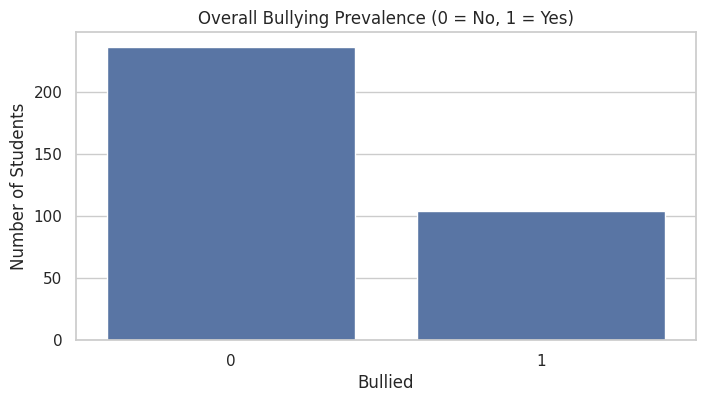

In [ ]:
# =====================================================
# EDA - PART 2: OVERALL BULLYING PREVALENCE
# =====================================================

bullying_risk_pct = df["bullied"].mean() * 100
print(f"🎯 Overall Bullying Risk: {bullying_risk_pct:.1f}%")

sns.countplot(x="bullied", data=df)
plt.title("Overall Bullying Prevalence (0 = No, 1 = Yes)")
plt.xlabel("Bullied")
plt.ylabel("Number of Students")
plt.show()



Bullying Risk by Gender (%):
gender
0    27.4
1    39.1
Name: bullied, dtype: float64


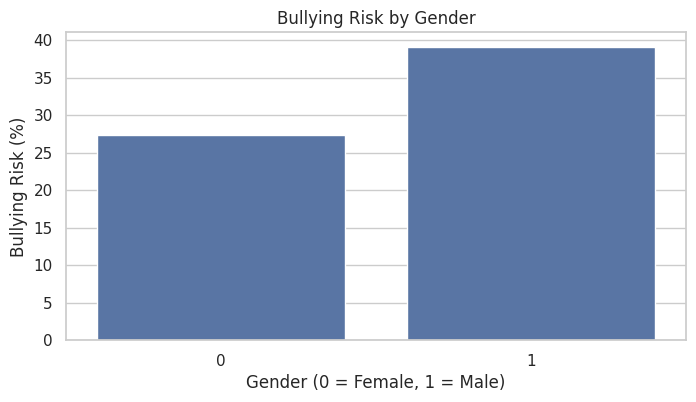

In [ ]:
# =====================================================
# EDA - PART 3: GENDER VS BULLYING RISK
# =====================================================

gender_risk = df.groupby("gender")["bullied"].mean() * 100
print("\nBullying Risk by Gender (%):")
print(gender_risk.round(1))

sns.barplot(x=gender_risk.index, y=gender_risk.values)
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Bullying Risk (%)")
plt.title("Bullying Risk by Gender")
plt.show()



Likelihood of Bullying Types (%):
bullying_verbal               71.2
bullying_relational_social    51.0
bullying_physical             25.0
bullying_cyber                16.3
bullying_sexual                8.7
dtype: float64


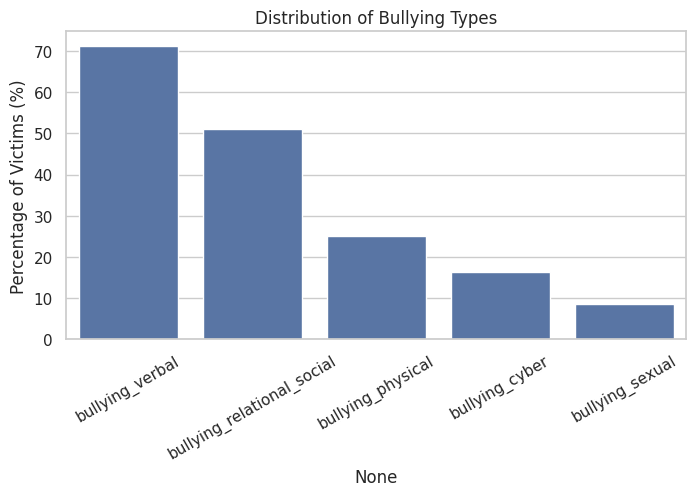

In [ ]:
# =====================================================
# EDA - PART 4: BULLYING TYPE DISTRIBUTION
# =====================================================

bullying_types = [
    "bullying_cyber",
    "bullying_verbal",
    "bullying_relational_social",
    "bullying_physical",
    "bullying_sexual"
]

bullying_type_pct = (df[bullying_types].sum() / df["bullied"].sum()) * 100
bullying_type_pct = bullying_type_pct.sort_values(ascending=False)

print("\nLikelihood of Bullying Types (%):")
print(bullying_type_pct.round(1))

sns.barplot(x=bullying_type_pct.index, y=bullying_type_pct.values)
plt.ylabel("Percentage of Victims (%)")
plt.title("Distribution of Bullying Types")
plt.xticks(rotation=30)
plt.show()


/tmp/ipython-input-1668246022.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  class_risk = df.groupby("class_size_bin")["bullied"].mean() * 100


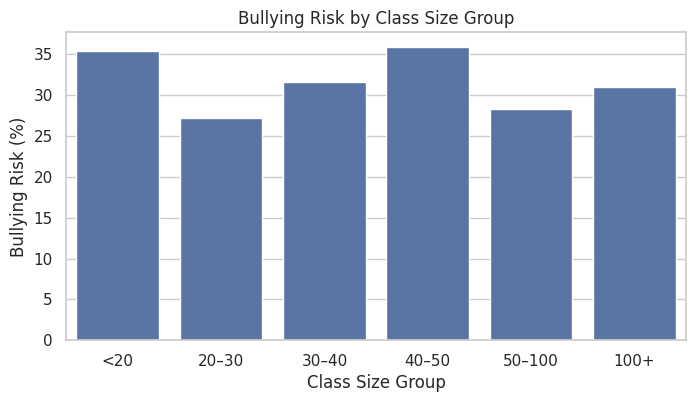

In [ ]:
# =====================================================
# EDA - PART 5: CLASS SIZE VS BULLYING RISK
# =====================================================
# Bin class sizes
df["class_size_bin"] = pd.cut(
    df["class_size"],
    bins=[0, 20, 30, 40, 50, 100, 200],
    labels=["<20", "20–30", "30–40", "40–50", "50–100", "100+"]
)

class_risk = df.groupby("class_size_bin")["bullied"].mean() * 100

sns.barplot(x=class_risk.index, y=class_risk.values)
plt.xlabel("Class Size Group")
plt.ylabel("Bullying Risk (%)")
plt.title("Bullying Risk by Class Size Group")
plt.show()


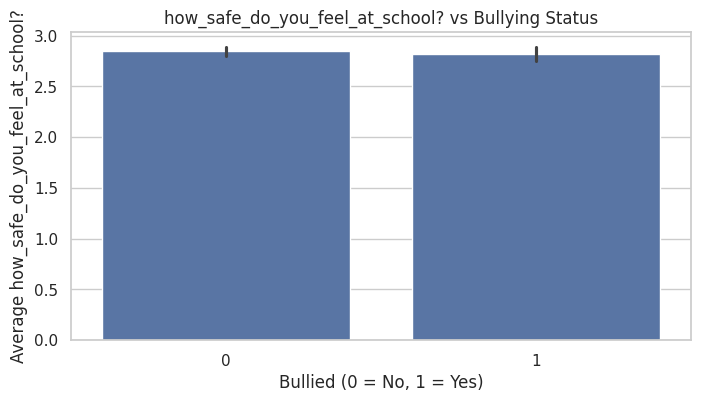

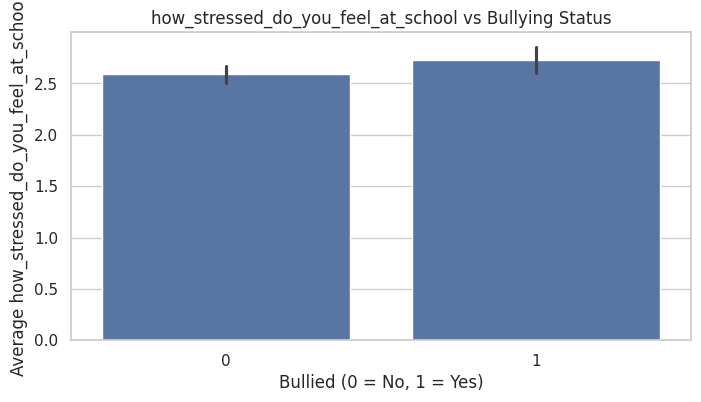

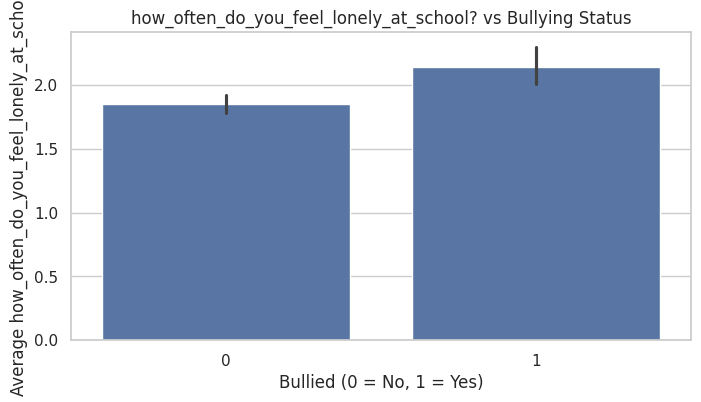

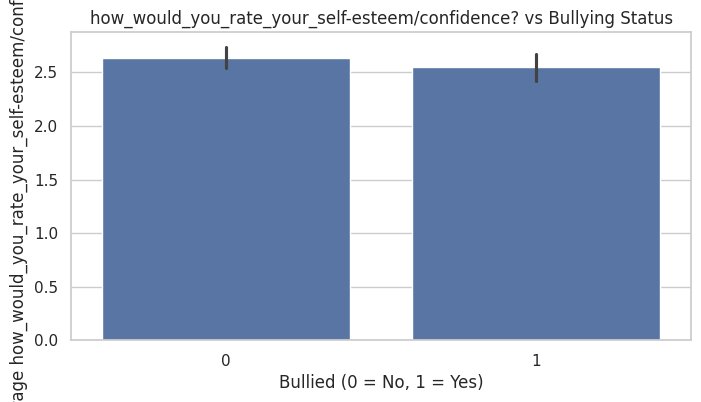

In [ ]:
# =====================================================
# EDA - PART 6: PSYCHOSOCIAL FACTORS VS BULLYING
# =====================================================

psychosocial_features = [
    "how_safe_do_you_feel_at_school?",
    "how_stressed_do_you_feel_at_school",
    "how_often_do_you_feel_lonely_at_school?",
    "how_would_you_rate_your_self-esteem/confidence?"
]

for col in psychosocial_features:
    sns.barplot(x="bullied", y=col, data=df)
    plt.xlabel("Bullied (0 = No, 1 = Yes)")
    plt.ylabel(f"Average {col}")
    plt.title(f"{col} vs Bullying Status")
    plt.show()


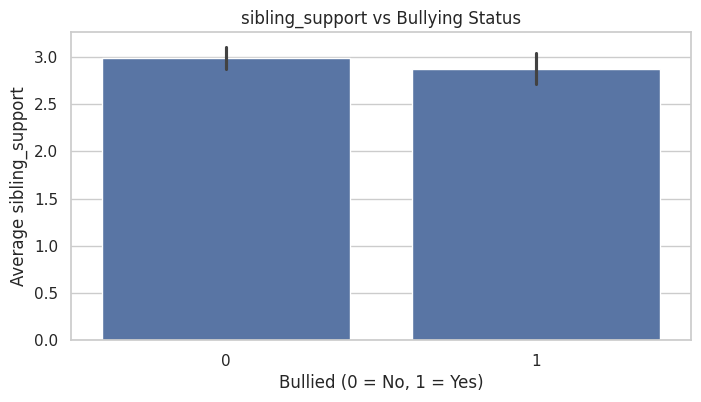

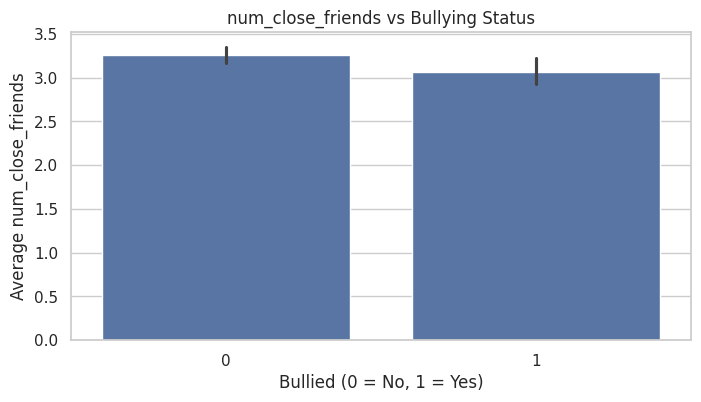

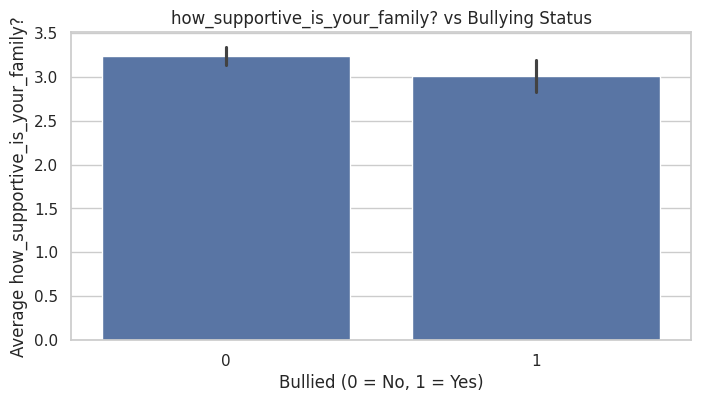

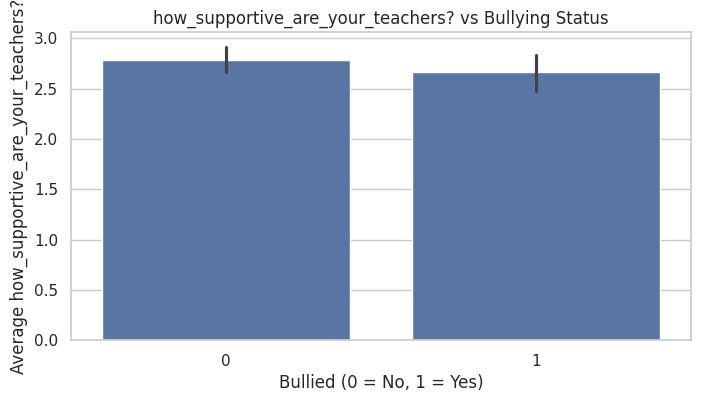

In [ ]:
# =====================================================
# EDA - PART 7: SUPPORT SYSTEMS VS BULLYING
# =====================================================

support_features = [
    "sibling_support",
    "num_close_friends",
    "how_supportive_is_your_family?",
    "how_supportive_are_your_teachers?"
]

for col in support_features:
    sns.barplot(x="bullied", y=col, data=df)
    plt.xlabel("Bullied (0 = No, 1 = Yes)")
    plt.ylabel(f"Average {col}")
    plt.title(f"{col} vs Bullying Status")
    plt.show()


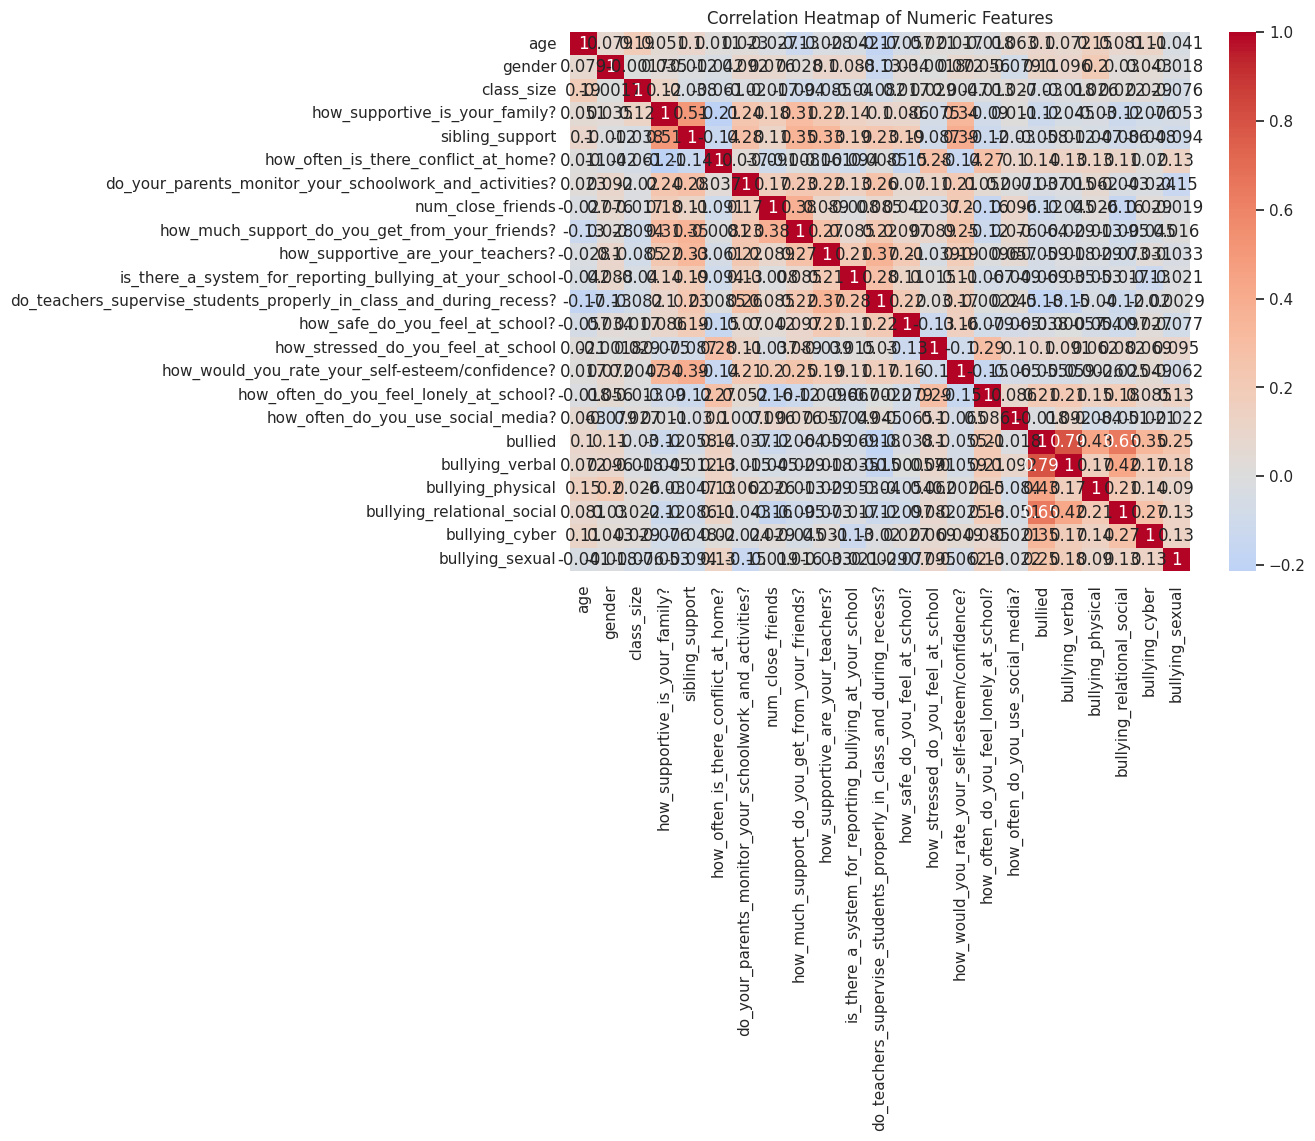

In [ ]:
# =====================================================
# EDA - PART 8: CORRELATION ANALYSIS
# =====================================================

plt.figure(figsize=(10, 7))
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    cmap="coolwarm",
    center=0,
    annot=True
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [ ]:
corr = df.select_dtypes(include="number").corr(method="spearman")


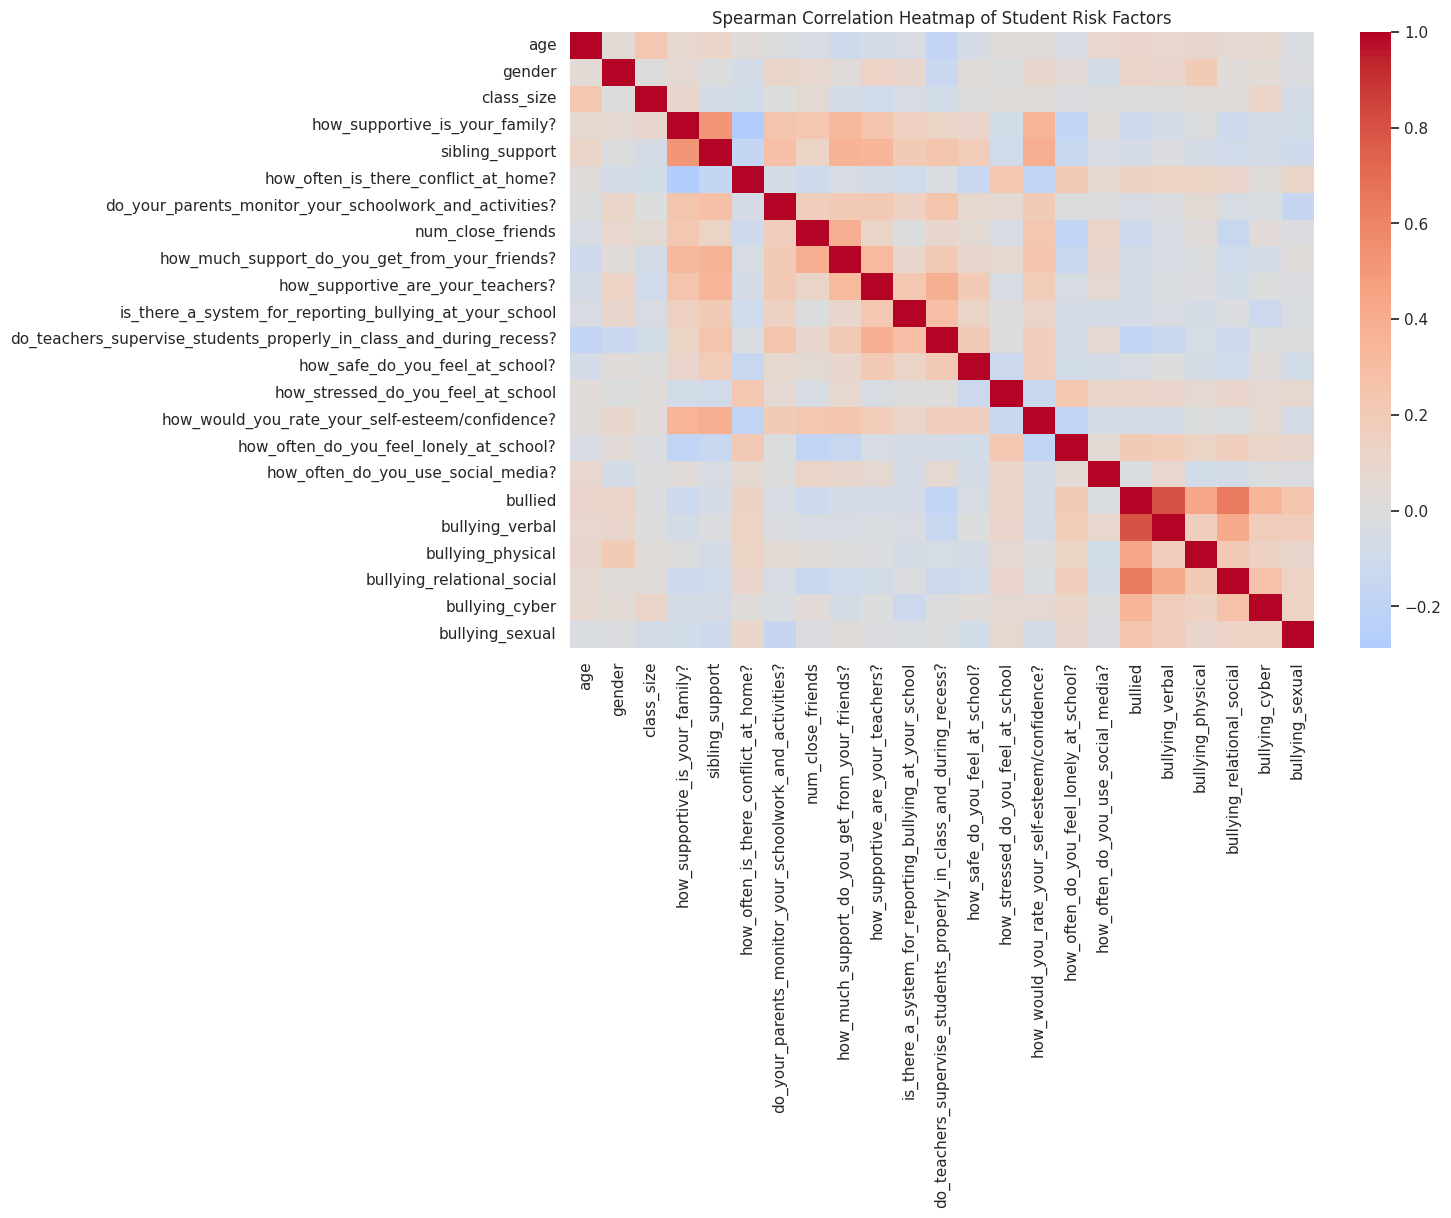

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Spearman Correlation Heatmap of Student Risk Factors")
plt.show()


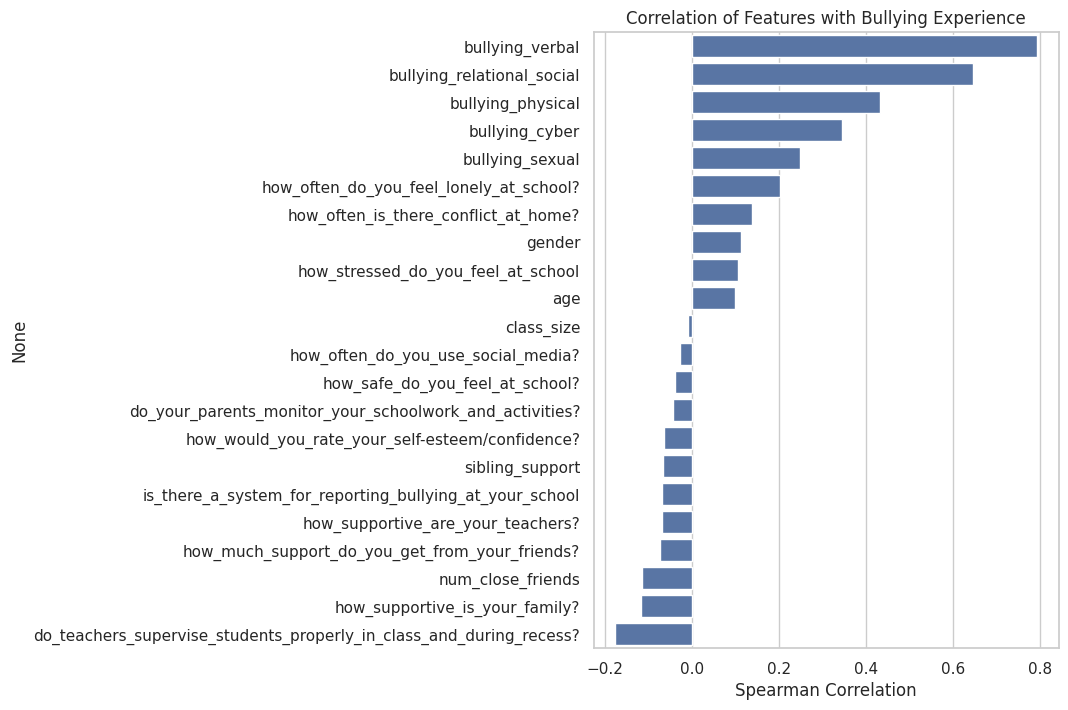

In [ ]:
bullied_corr = corr["bullied"].drop("bullied").sort_values(ascending=False)

plt.figure(figsize=(6, 8))
sns.barplot(
    x=bullied_corr.values,
    y=bullied_corr.index
)
plt.title("Correlation of Features with Bullying Experience")
plt.xlabel("Spearman Correlation")
plt.show()


In [ ]:
# =====================================================
# EDA - PART 9: KEY EDA INSIGHTS (SUMMARY)
# =====================================================

print("""
KEY EDA INSIGHTS (DESCRIPTIVE ANALYSIS):

• Approximately 30.6% of students reported experiencing bullying.
• Male students show higher bullying risk compared to female students.
• Verbal bullying is the most common type, followed by relational bullying.
• Bullying risk varies across class sizes; extreme values may be due to small sample sizes.
• Bullied students report higher stress and loneliness, and lower perceived safety.
• Strong family, teacher, and peer support is associated with lower bullying prevalence.
""")




KEY EDA INSIGHTS (DESCRIPTIVE ANALYSIS):

• Approximately 30.6% of students reported experiencing bullying.
• Male students show higher bullying risk compared to female students.
• Verbal bullying is the most common type, followed by relational bullying.
• Bullying risk varies across class sizes; extreme values may be due to small sample sizes.
• Bullied students report higher stress and loneliness, and lower perceived safety.
• Strong family, teacher, and peer support is associated with lower bullying prevalence.



✅ Data split and scaling complete
Train: (204, 9) Validation: (68, 9) Test: (68, 9)

=== BASELINE MODEL COMPARISON ===
                 Model  Accuracy  F1-score
2              XGBoost  0.661765  0.566038
1        Random Forest  0.514706  0.476190
0  Logistic Regression  0.485294  0.385965

=== Tuning Logistic Regression ===
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

=== Tuning Random Forest ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

=== Tuning XGBoost ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

=== MODEL COMPARISON (Validation F2) ===
                 Model  Accuracy (Val)  F2-score (Val)  Best Threshold
1        Random Forest        0.470588        0.719424            0.40
2              XGBoost  

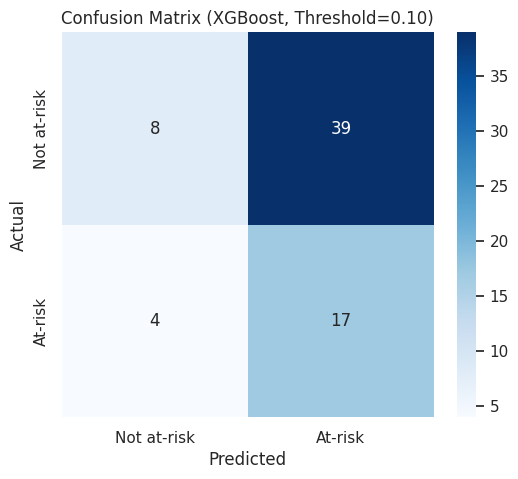


🎯 Feature Importances (XGBoost):
                                           Feature  Importance
3          how_often_do_you_feel_lonely_at_school?    0.261529
8                how_supportive_are_your_teachers?    0.175090
5                                  sibling_support    0.152409
4  how_would_you_rate_your_self-esteem/confidence?    0.106848
0                                       class_size    0.066290
6                                num_close_friends    0.061133
2               how_stressed_do_you_feel_at_school    0.059058
1                  how_safe_do_you_feel_at_school?    0.058929
7                   how_supportive_is_your_family?    0.058713


/tmp/ipython-input-3039711846.py:212: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_importances, palette="viridis")


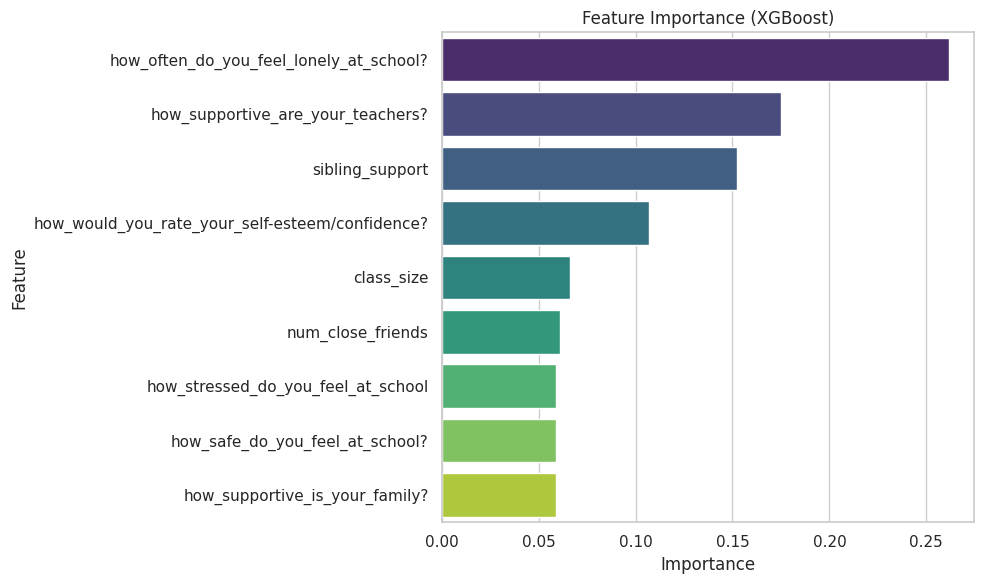

In [ ]:
# =================================
# PART 1: DATA PREPARATION
# =================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

final_features = [
    "class_size",
    "how_safe_do_you_feel_at_school?",
    "how_stressed_do_you_feel_at_school",
    "how_often_do_you_feel_lonely_at_school?",
    "how_would_you_rate_your_self-esteem/confidence?",
    "sibling_support",
    "num_close_friends",
    "how_supportive_is_your_family?",
    "how_supportive_are_your_teachers?"
]

target = "bullied"

# Fill missing values
df[final_features] = df[final_features].fillna(df[final_features].median())

X = df[final_features].copy()
y = df[target]

# -------------------------
# Train / Validation / Test Split (60/20/20)
# -------------------------
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# -------------------------
# Scaling
# -------------------------
scaler = StandardScaler()
X_train_scaled = X_train_full.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[final_features] = scaler.fit_transform(X_train_full[final_features])
X_val_scaled[final_features] = scaler.transform(X_val[final_features])
X_test_scaled[final_features] = scaler.transform(X_test[final_features])

print("✅ Data split and scaling complete")
print("Train:", X_train_scaled.shape, "Validation:", X_val_scaled.shape, "Test:", X_test_scaled.shape)

# =================================
# PART 2: HANDLE CLASS IMBALANCE (TRAIN ONLY)
# =================================
from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN(random_state=42)
X_train_bal, y_train_bal = smote_enn.fit_resample(X_train_scaled, y_train_full)

# =================================
# PART 3: BASELINE MODEL COMPARISON (ON VALIDATION)
# =================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=(sum(y_train_full == 0)/sum(y_train_full==1)),
        eval_metric='logloss',
        random_state=42
    )
}

print("\n=== BASELINE MODEL COMPARISON ===")
baseline_results = []

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_val_scaled)  # baseline on validation
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    baseline_results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-score": f1
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("F1-score", ascending=False)
print(baseline_df)

# =================================
# PART 4: HYPERPARAMETER TUNING + THRESHOLD OPTIMIZATION
# =================================
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import fbeta_score, make_scorer

f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

param_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        "params": {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"], "solver": ["lbfgs"]}
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight='balanced', random_state=42),
        "params": {"n_estimators": [100, 200], "max_depth": [None,5,10], "min_samples_split":[2,5]}
    },
    "XGBoost": {
        "model": xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42),
        "params": {"n_estimators":[100,200], "max_depth":[3,5,7], "learning_rate":[0.01,0.1,0.2], "subsample":[0.8,1]}
    }
}

tuned_results = []
tuned_models = {}

for name, cfg in param_grids.items():
    print(f"\n=== Tuning {name} ===")
    grid = GridSearchCV(cfg["model"], cfg["params"], scoring=f2_scorer, cv=5, n_jobs=-1, verbose=1)
    grid.fit(X_train_bal, y_train_bal)
    best_model = grid.best_estimator_
    tuned_models[name] = best_model
    print("Best Params:", grid.best_params_)

    # -------------------------
    # THRESHOLD OPTIMIZATION (VALIDATION SET)
    # -------------------------
    y_val_prob = best_model.predict_proba(X_val_scaled)[:,1]
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f2 = 0
    best_threshold = 0.5

    for t in thresholds:
        y_val_pred = (y_val_prob >= t).astype(int)
        f2 = fbeta_score(y_val, y_val_pred, beta=2)
        if f2 > best_f2:
            best_f2 = f2
            best_threshold = t

    y_val_pred_final = (y_val_prob >= best_threshold).astype(int)
    acc = accuracy_score(y_val, y_val_pred_final)

    tuned_results.append({
        "Model": name,
        "Accuracy (Val)": acc,
        "F2-score (Val)": best_f2,
        "Best Threshold": best_threshold
    })

tuned_df = pd.DataFrame(tuned_results).sort_values("F2-score (Val)", ascending=False)
print("\n=== MODEL COMPARISON (Validation F2) ===")
print(tuned_df)

# =================================
# FINAL EVALUATION USING XGBOOST
# =================================
final_model_name = "XGBoost"
final_model = tuned_models[final_model_name]
final_threshold = tuned_df.loc[tuned_df['Model']==final_model_name,'Best Threshold'].values[0]

# Predict probabilities on test set
y_test_prob = final_model.predict_proba(X_test_scaled)[:,1]
y_test_final = (y_test_prob >= final_threshold).astype(int)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
print(f"\n✅ FINAL DEPLOYMENT MODEL: {final_model_name}")
print(f"Threshold: {final_threshold:.2f}")
print("\n📊 Classification Report (Test Set)")
print(classification_report(y_test, y_test_final, digits=3))

# Confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not at-risk","At-risk"],
            yticklabels=["Not at-risk","At-risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix ({final_model_name}, Threshold={final_threshold:.2f})")
plt.show()

# Feature importance
import matplotlib.pyplot as plt
import pandas as pd

# Get XGBoost feature importances
feat_importances = pd.DataFrame({
    "Feature": X_train_bal.columns,
    "Importance": final_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n🎯 Feature Importances (XGBoost):")
print(feat_importances)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_importances, palette="viridis")
plt.title(f"Feature Importance ({final_model_name})")
plt.tight_layout()
plt.show()


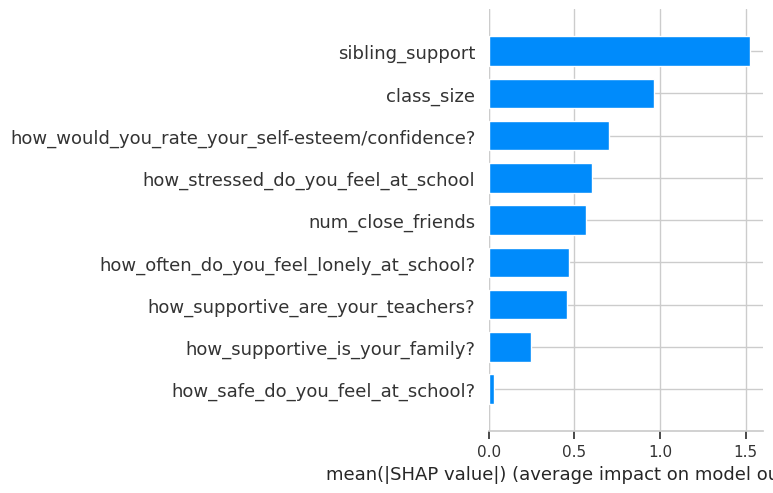

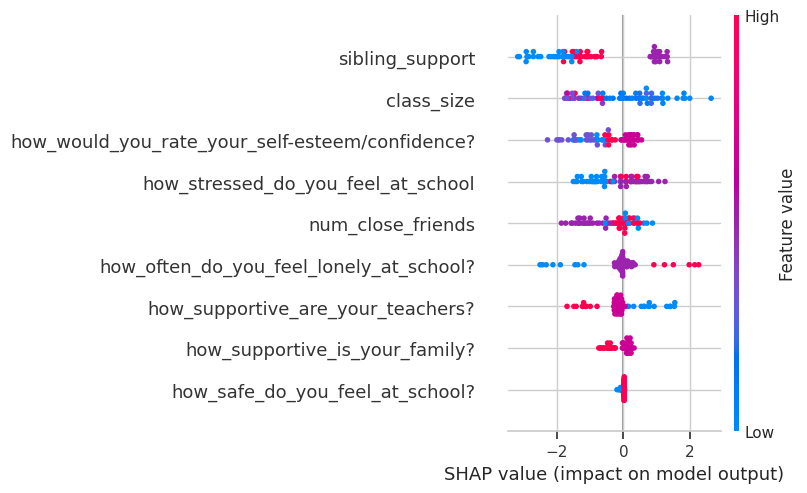

In [ ]:
import shap

# Explainer for XGBoost
explainer = shap.Explainer(final_model, X_train_bal)
shap_values = explainer(X_test_scaled)

# Summary plot: importance + direction
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar")
shap.summary_plot(shap_values, X_test_scaled)  # dot plot shows increase/decrease


In [ ]:
import pandas as pd

# For first student
shap_vals_single = shap_values[0].values  # get numeric values

shap_df = pd.DataFrame({
    "Feature": final_features,
    "SHAP_value": shap_vals_single
})

# Sort by absolute SHAP value
shap_df = shap_df.reindex(shap_df["SHAP_value"].abs().sort_values(ascending=False).index)

print(shap_df)


                                           Feature  SHAP_value
5                                  sibling_support   -1.630841
6                                num_close_friends   -1.566493
0                                       class_size   -0.627079
2               how_stressed_do_you_feel_at_school   -0.609796
4  how_would_you_rate_your_self-esteem/confidence?    0.228496
8                how_supportive_are_your_teachers?   -0.125209
3          how_often_do_you_feel_lonely_at_school?    0.115564
7                   how_supportive_is_your_family?    0.102150
1                  how_safe_do_you_feel_at_school?    0.025694


In [ ]:
import shap
import pandas as pd
import numpy as np

# =================================
# SHAP EXPLAINER
# =================================
explainer = shap.Explainer(final_model, X_train_bal)
shap_values = explainer(X_test_scaled)  # SHAP values for test set

# Convert SHAP values to DataFrame for easier interpretation
shap_df = pd.DataFrame(shap_values.values, columns=X_test_scaled.columns)
shap_df["predicted_risk"] = final_model.predict_proba(X_test_scaled)[:,1]

# Rank features for each student
def rank_features(row):
    df = pd.DataFrame({
        "Feature": X_test_scaled.columns,
        "SHAP_value": row[X_test_scaled.columns].values
    })
    df["Effect"] = df["SHAP_value"].apply(lambda x: "↑ increase risk" if x > 0 else "↓ decrease risk")
    df = df.sort_values("SHAP_value", key=abs, ascending=False).reset_index(drop=True)
    return df

# Example: show top features for first student
student0_ranked = rank_features(shap_df.iloc[0])
print("=== Student 0 Feature Ranking ===")
print(student0_ranked)

# =================================
# OPTIONAL: Average SHAP effect across all students
# =================================
avg_shap = pd.DataFrame({
    "Feature": X_test_scaled.columns,
    "Mean_SHAP": np.mean(shap_values.values, axis=0)
})
avg_shap["Effect"] = avg_shap["Mean_SHAP"].apply(lambda x: "↑ increase risk" if x > 0 else "↓ decrease risk")
avg_shap = avg_shap.sort_values("Mean_SHAP", key=abs, ascending=False).reset_index(drop=True)

print("\n=== Average Feature Effect Across All Students ===")
print(avg_shap)


=== Student 0 Feature Ranking ===
                                           Feature  SHAP_value  \
0                                  sibling_support   -1.630841   
1                                num_close_friends   -1.566493   
2                                       class_size   -0.627079   
3               how_stressed_do_you_feel_at_school   -0.609796   
4  how_would_you_rate_your_self-esteem/confidence?    0.228496   
5                how_supportive_are_your_teachers?   -0.125209   
6          how_often_do_you_feel_lonely_at_school?    0.115564   
7                   how_supportive_is_your_family?    0.102150   
8                  how_safe_do_you_feel_at_school?    0.025694   

            Effect  
0  ↓ decrease risk  
1  ↓ decrease risk  
2  ↓ decrease risk  
3  ↓ decrease risk  
4  ↑ increase risk  
5  ↓ decrease risk  
6  ↑ increase risk  
7  ↑ increase risk  
8  ↑ increase risk  

=== Average Feature Effect Across All Students ===
                                           

//JUST TO VISUALIZE THE SMOOTEEN

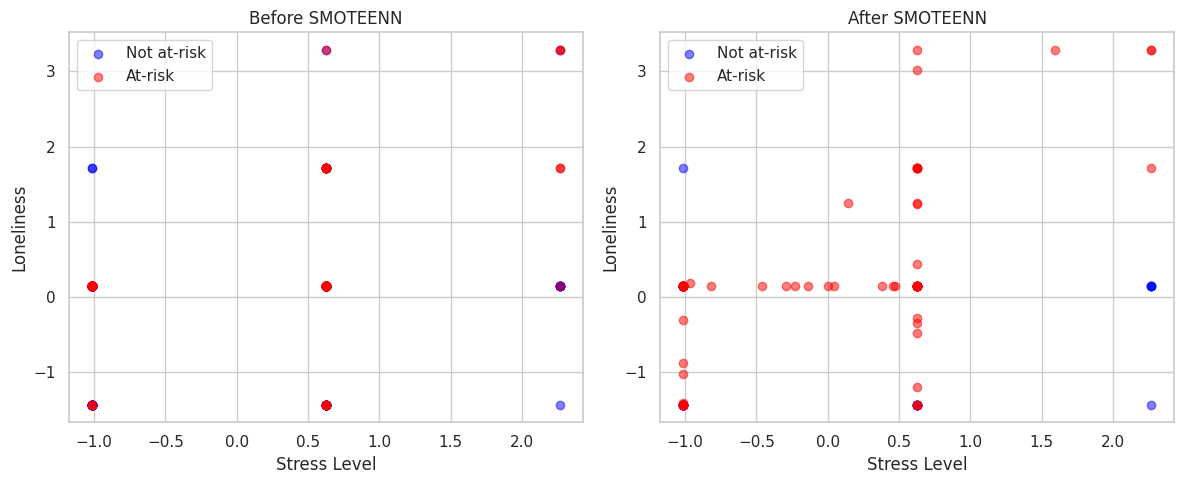

In [ ]:
import matplotlib.pyplot as plt
from imblearn.combine import SMOTEENN
import numpy as np
import pandas as pd

# Example: use first two features for visualization
X_vis = X_train_scaled[["how_stressed_do_you_feel_at_school", "how_often_do_you_feel_lonely_at_school?"]].copy()
y_vis = y_train_full.copy()

# ----------------------
# Before SMOTEENN
# ----------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_vis[y_vis==0].iloc[:,0], X_vis[y_vis==0].iloc[:,1], label="Not at-risk", alpha=0.5, c='blue')
plt.scatter(X_vis[y_vis==1].iloc[:,0], X_vis[y_vis==1].iloc[:,1], label="At-risk", alpha=0.5, c='red')
plt.title("Before SMOTEENN")
plt.xlabel("Stress Level")
plt.ylabel("Loneliness")
plt.legend()

# ----------------------
# Apply SMOTEENN
# ----------------------
smote_enn = SMOTEENN(random_state=42)
X_res, y_res = smote_enn.fit_resample(X_train_scaled, y_train_full)

X_res_vis = pd.DataFrame(X_res, columns=X_train_scaled.columns)
y_res_vis = pd.Series(y_res)

plt.subplot(1,2,2)
plt.scatter(X_res_vis[y_res_vis==0]["how_stressed_do_you_feel_at_school"],
            X_res_vis[y_res_vis==0]["how_often_do_you_feel_lonely_at_school?"],
            label="Not at-risk", alpha=0.5, c='blue')
plt.scatter(X_res_vis[y_res_vis==1]["how_stressed_do_you_feel_at_school"],
            X_res_vis[y_res_vis==1]["how_often_do_you_feel_lonely_at_school?"],
            label="At-risk", alpha=0.5, c='red')
plt.title("After SMOTEENN")
plt.xlabel("Stress Level")
plt.ylabel("Loneliness")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
y_train_full.value_counts(normalize=True)


,proportion
bullied,
0,0.696078
1,0.303922


Deployment

In [ ]:
import joblib

# Prepare components to export
deployment_assets = {
    "model": final_model,        # Trained XGBoost model
    "scaler": scaler,            # StandardScaler used for feature scaling
    "features": final_features,  # List of feature names
    "threshold": final_threshold # Optimized classification threshold
}

# Export as a single .pkl file
joblib.dump(deployment_assets, "bullying_risk_model_xgboost.pkl")
print("✅ Model, scaler, and deployment assets exported successfully.")


✅ Model, scaler, and deployment assets exported successfully.
